# create scalar field

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# helper function
def _get_min_max(f_1, f_2, f_3, p0=0, p1=100):
    vmin = np.min([np.percentile(f_1, p0), np.percentile(f_2, p0), np.percentile(f_3, p0)])
    vmax = np.max([np.percentile(f_1, p1), np.percentile(f_2, p1), np.percentile(f_3, p1)])
    return vmin, vmax

# simple scalar field with given power spectrum

In [3]:
N = 128
p = 11.0/3.0
p_str = "11_3"

def _create_field(N, p):
    kx = np.fft.fftfreq(N) * N
    ky = np.fft.fftfreq(N) * N
    kz = np.fft.fftfreq(N) * N
    
    KX,KY,KZ = np.meshgrid(
        kx,ky,kz,indexing="ij"
    )
    
    K = np.sqrt(KX**2 + KY**2 + KZ**2)
    
    P = np.where(K>0, K**(-p), 0.0)
    
    phase = np.random.uniform(
        0,2*np.pi,size=(N,N,N)
    )
    
    F = np.sqrt(P) * np.exp(1j*phase)
    
    field = np.real(np.fft.ifftn(F))

    return field

field = _create_field(N, p)

/var/folders/lq/sxc6dpqd4l15_k4s7smgt4sc0000gn/T/ipykernel_15605/3581367553.py:16: RuntimeWarning: divide by zero encountered in power
  P = np.where(K>0, K**(-p), 0.0)


(array([1.00000e+01, 5.50000e+01, 1.35000e+02, 2.56000e+02, 5.40000e+02,
        9.05000e+02, 1.57500e+03, 2.89100e+03, 5.04800e+03, 8.35300e+03,
        1.26130e+04, 1.92990e+04, 2.86730e+04, 4.11930e+04, 5.68190e+04,
        7.57150e+04, 9.60250e+04, 1.19022e+05, 1.42542e+05, 1.62997e+05,
        1.77958e+05, 1.82029e+05, 1.77931e+05, 1.65040e+05, 1.45554e+05,
        1.22126e+05, 9.74120e+04, 7.57640e+04, 5.78590e+04, 4.31060e+04,
        3.05320e+04, 2.03970e+04, 1.27760e+04, 7.43300e+03, 3.79400e+03,
        1.76400e+03, 6.48000e+02, 2.63000e+02, 7.30000e+01, 2.70000e+01]),
 array([-7.37956291e-06, -7.03633887e-06, -6.69311484e-06, -6.34989080e-06,
        -6.00666676e-06, -5.66344272e-06, -5.32021868e-06, -4.97699464e-06,
        -4.63377061e-06, -4.29054657e-06, -3.94732253e-06, -3.60409849e-06,
        -3.26087445e-06, -2.91765041e-06, -2.57442638e-06, -2.23120234e-06,
        -1.88797830e-06, -1.54475426e-06, -1.20153022e-06, -8.58306186e-07,
        -5.15082147e-07, -1.718581

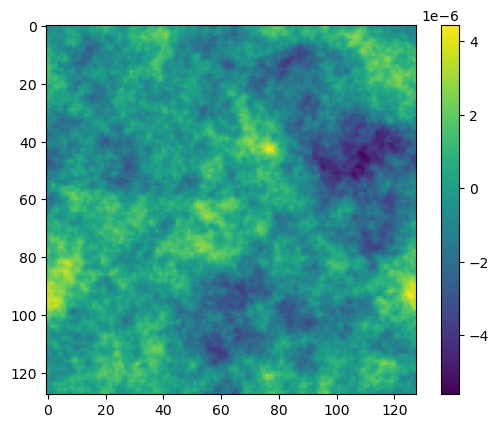

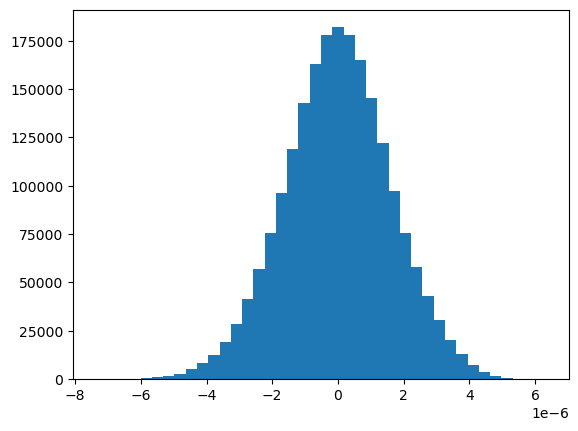

In [4]:
# do a raw plot of the data
fig, ax = plt.subplots()
im = ax.imshow(field[:,:,N//2])
cbar = plt.colorbar(im)

fig, ax = plt.subplots()
ax.hist(field.flatten(),bins=40)

# illustrate different realisations

/var/folders/lq/sxc6dpqd4l15_k4s7smgt4sc0000gn/T/ipykernel_15614/3581367553.py:16: RuntimeWarning: divide by zero encountered in power
  P = np.where(K>0, K**(-p), 0.0)


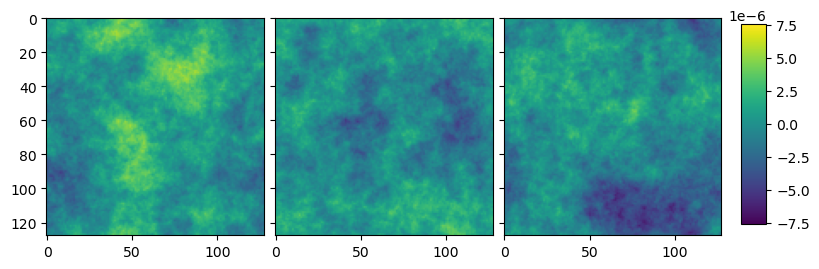

In [13]:
# loop over different realisations
f_1 = _create_field(N,p)
f_2 = _create_field(N,p)
f_3 = _create_field(N,p)

vmin, vmax = _get_min_max(f_1, f_2, f_3)

fig, axs = plt.subplots(figsize=(10,4),ncols=3,sharey=True)
im = axs[0].imshow(f_1[:,:,N//2], vmin=vmin, vmax=vmax)
im = axs[1].imshow(f_2[:,:,N//2], vmin=vmin, vmax=vmax)
im = axs[2].imshow(f_3[:,:,N//2], vmin=vmin, vmax=vmax)

fig.subplots_adjust(right=0.8, wspace=0.05)
cbar_ax = fig.add_axes([0.82, 0.25, 0.025, 0.5])
fig.colorbar(im, cax=cbar_ax)

In [7]:
# store data for later
np.save("data/field-cube-N"+str(N)+"-p"+p_str+"-real1.npy", f_1)
np.save("data/field-cube-N"+str(N)+"-p"+p_str+"-real2.npy", f_2)
np.save("data/field-cube-N"+str(N)+"-p"+p_str+"-real3.npy", f_1)

# illustrate differences in the spectral index

/var/folders/lq/sxc6dpqd4l15_k4s7smgt4sc0000gn/T/ipykernel_15614/3581367553.py:16: RuntimeWarning: divide by zero encountered in power
  P = np.where(K>0, K**(-p), 0.0)


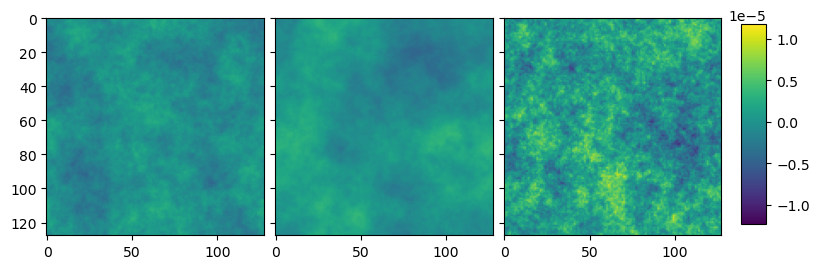

In [14]:
# loop over different spectral indices
f_1 = _create_field(N,2+5./3.)
f_2 = _create_field(N,4)
f_3 = _create_field(N,3)

vmin, vmax = _get_min_max(f_1, f_2, f_3)

fig, axs = plt.subplots(figsize=(10,4),ncols=3,sharey=True)
im = axs[0].imshow(f_1[:,:,N//2], vmin=vmin, vmax=vmax)
im = axs[1].imshow(f_2[:,:,N//2], vmin=vmin, vmax=vmax)
im = axs[2].imshow(f_3[:,:,N//2], vmin=vmin, vmax=vmax)

fig.subplots_adjust(right=0.8, wspace=0.05)
cbar_ax = fig.add_axes([0.82, 0.25, 0.025, 0.5])
fig.colorbar(im, cax=cbar_ax)